# JURNAL MODUL 2
TEGU ILHAM PEBRIAN SAPUTRA F1D02410097

In [148]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Citra 1')

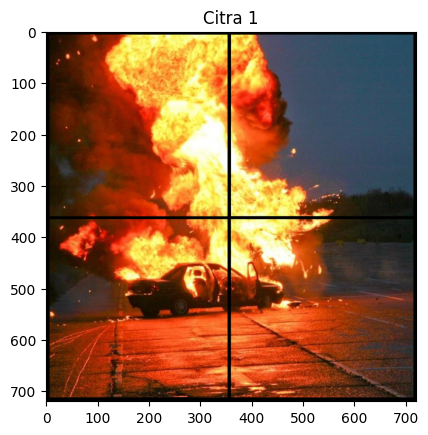

In [149]:
citra1 = cv.imread('Assets/Meledak.png')
citra_asli = cv.cvtColor(citra1, cv.COLOR_BGR2RGB)
plt.imshow(citra_asli)
plt.title("Citra 1")

###   POTONG CITRA

Text(0.5, 1.0, 'Part4')

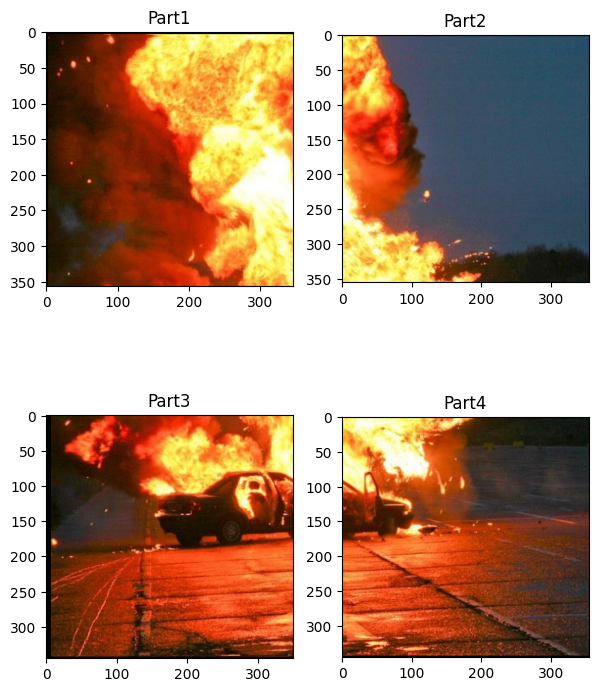

In [150]:
def fungsi_slicing(gambar, a, b, mode='H'):
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

potong1 = fungsi_slicing(citra_asli, 4, 360)
gambar_1 = fungsi_slicing(potong1, 4, 350, 'V')
gambar_2 = fungsi_slicing(potong1, 360, 715, 'V')

potong2 = fungsi_slicing(citra_asli, 370, 715)
gambar_3 = fungsi_slicing(potong2, 0, 350, 'V')
gambar_4 = fungsi_slicing(potong2, 360, 715, 'V')

plt.figure(figsize=(7, 9))

plt.subplot(2, 2, 1)
plt.imshow(gambar_1)
plt.title("Part1")

plt.subplot(2, 2, 2)
plt.imshow(gambar_2)
plt.title("Part2")

plt.subplot(2, 2, 3)
plt.imshow(gambar_3)
plt.title("Part3")

plt.subplot(2, 2, 4)
plt.imshow(gambar_4)
plt.title("Part4")

###   PENGGABUNGAN

(701, 705, 3)


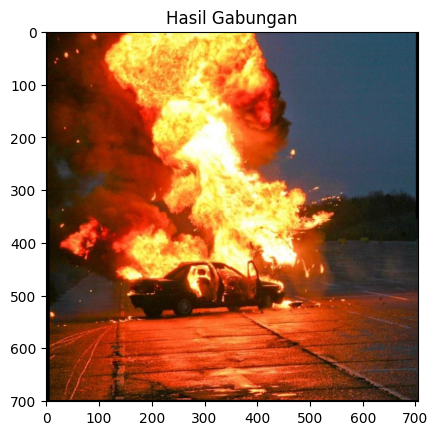

In [151]:
def merge_image(citra1, citra2, orientation='H'): 
     
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
     
    return gabungan

gabung1 = merge_image(gambar_1, gambar_2, 'H')
gabung2 = merge_image(gambar_3, gambar_4, 'H')
gabung3 = merge_image(gabung1, gabung2, 'v')
plt.imshow(gabung3)
plt.title("Hasil Gabungan")

print(gabung3.shape)

###  GRAYSCALE

(701, 705)


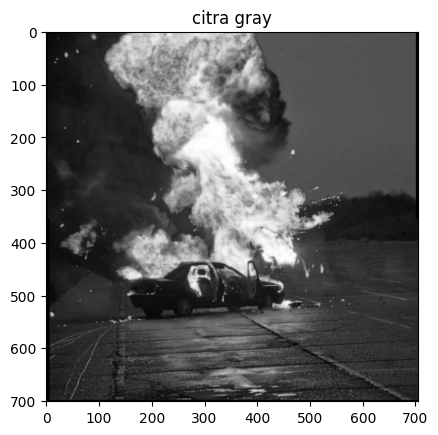

In [152]:
citra_gray = cv.cvtColor(gabung3, cv.COLOR_BGR2GRAY)
plt.imshow(citra_gray, cmap='gray')
plt.title("citra gray")

print(citra_gray.shape)

###   EKUALISASI

(701, 705)


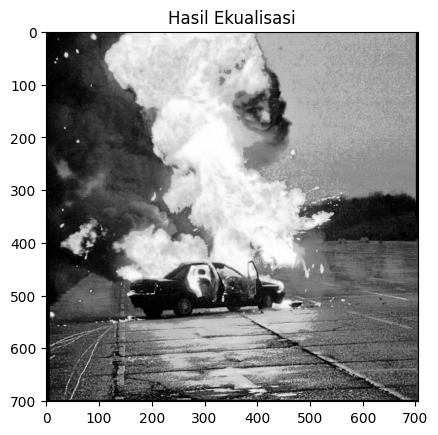

In [153]:
def ekualisasi(citra):
    h, w = citra.shape

    hist = np.zeros(256, dtype=int)
    for i in range(h):
        for j in range(w):
            intensitas = citra[i, j]
            hist[intensitas] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    cdf_normal = np.round(cdf * 255 / (h * w)).astype(np.uint8)
    hasil = np.zeros_like(citra, dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            hasil[i, j] = cdf_normal[citra[i, j]]

    return hasil

hasil_ekualisasi = ekualisasi(citra_gray)
plt.imshow(hasil_ekualisasi, cmap='gray')
plt.title("Hasil Ekualisasi")

print(hasil_ekualisasi.shape)

### HISTOGRAM

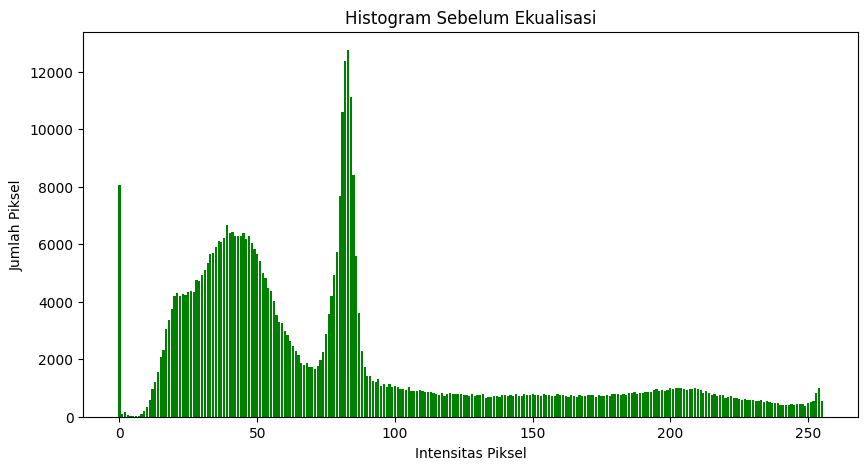

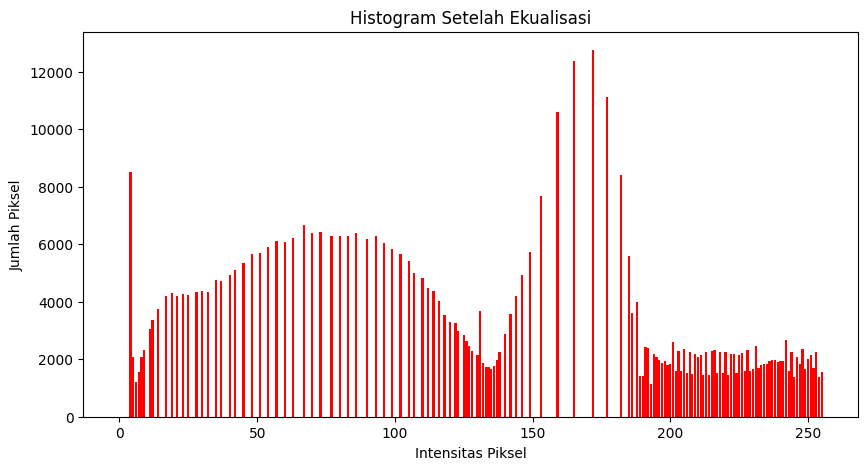

In [154]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
 
    return histogram 
def plot_histogram(histogram, title, ImgColor): 
    plt.figure(figsize=(10, 5)) 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 
    plt.show()

hasil_hist = buat_hist(citra_gray)
plot_histogram(hasil_hist, 'Histogram Sebelum Ekualisasi', 'green')

hasil_hist2 = buat_hist(hasil_ekualisasi)
plot_histogram(hasil_hist2, 'Histogram Setelah Ekualisasi', 'red')

###   Gabung Windut dan Bungan Ireng (SPESIFIKASI)

Text(0.5, 1.0, 'Citra Bunga Ireng')

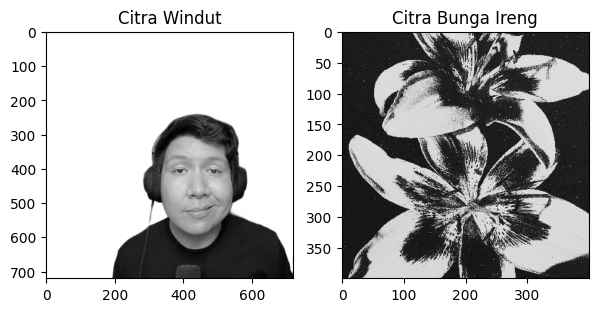

In [155]:
ctr_bunga = cv.imread('Assets/Bunga.png', cv.IMREAD_GRAYSCALE)
ctr_windut = cv.imread('Assets/Windut.png', cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(7, 10))

plt.subplot(1, 2, 1)
plt.imshow(ctr_windut, cmap='gray')
plt.title("Citra Windut")

plt.subplot(1, 2, 2)
plt.imshow(ctr_bunga, cmap='gray')
plt.title("Citra Bunga Ireng")

(720, 720)


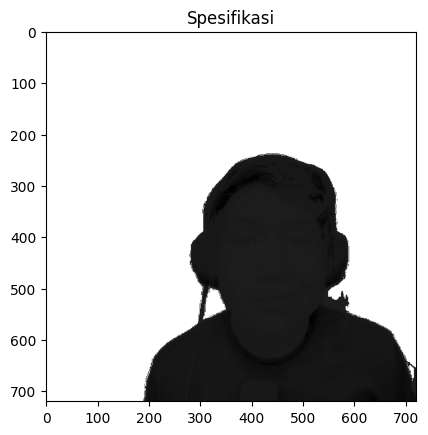

In [156]:
def spesifikasi_hist(citra_asal, citra_target): 
    hist_asal = np.zeros(256, dtype=int) 
    hist_target = np.zeros(256, dtype=int) 
    height_asal, width_asal = citra_asal.shape
    for i in range(height_asal):
        for j in range(width_asal):
            pixel = citra_asal[i, j]
            hist_asal[pixel] += 1
 
    height_target, width_target = citra_target.shape
    for i in range(height_target):
        for j in range(width_target):
            pixel = citra_target[i, j]
            hist_target[pixel] += 1
 
    cdf_asal = np.zeros(256, dtype=float) 
    cdf_target = np.zeros(256, dtype=float) 
 
    cdf_asal[0] = hist_asal[0] 
    cdf_target[0] = hist_target[0] 
 
    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i - 1] + hist_asal[i]
        cdf_target[i] = cdf_target[i - 1] + hist_target[i]
 
    cdf_asal = cdf_asal / cdf_asal[-1] 
    cdf_target = cdf_target / cdf_target[-1] 
 
    map_hist = np.zeros(256, dtype=np.uint8) 
 
    for i in range(256):
        selisih_terkecil = 1.0 
        index_target = 0
        for j in range(256):
            selisih = abs(cdf_asal[i] - cdf_target[j])
            if selisih < selisih_terkecil:
                selisih_terkecil = selisih
                index_target = j
        map_hist[i] = index_target
 
    height, width = citra_asal.shape 
    hasil = np.zeros((height, width), dtype=np.uint8) 
 
    for i in range(height):
        for j in range(width):
            pixel_lama = citra_asal[i, j]
            hasil[i, j] = map_hist[pixel_lama]
 
    return hasil

spesifikasi = spesifikasi_hist(ctr_windut, ctr_bunga)
plt.imshow(spesifikasi, cmap='gray')
plt.title("Spesifikasi")

print(spesifikasi.shape)

###   HISTOGRAM WINDUT

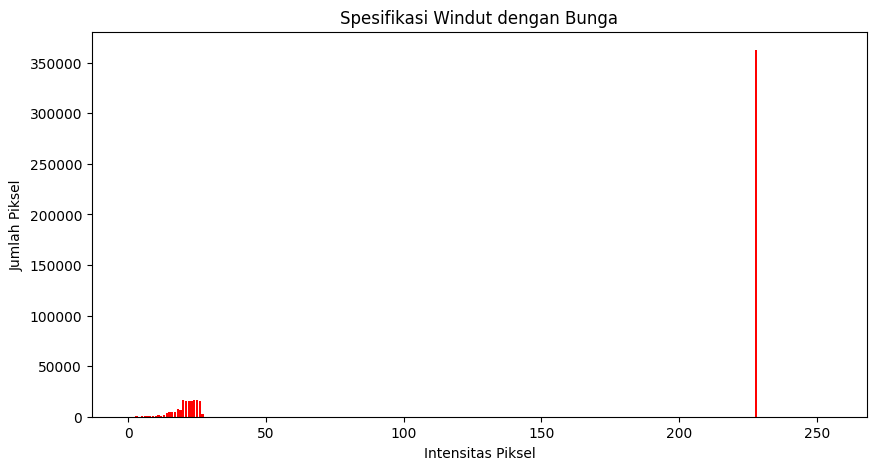

In [157]:
hasil_hist_spesifikasi = buat_hist(spesifikasi)
plot_histogram(hasil_hist_spesifikasi, 'Spesifikasi Windut dengan Bunga', 'red')